
#  MATH/CSCI 485 — Assignment #3: Image Compression via Block-wise SVD
#
# **Objective:** Explore Singular Value Decomposition (SVD) for compressing grayscale images
# using a block-wise approach. We retain only the top-*k* singular values per 8×8 block
# and analyze image quality vs. compression ratio as *k* varies from 1 to 8.

# 1. Imports & Setup


In [1]:


import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from google.colab import files
import os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("compressed_images", exist_ok=True)



#  2. Upload & Preprocess Image
#

# It will be converted to grayscale and resized to 512×512 (divisible by 8).

Please upload an image file (JPG, PNG, etc.):


Saving Me.jpg to Me.jpg

✅ Image loaded: 'Me.jpg'  |  Shape: (512, 512)  |  dtype: float64


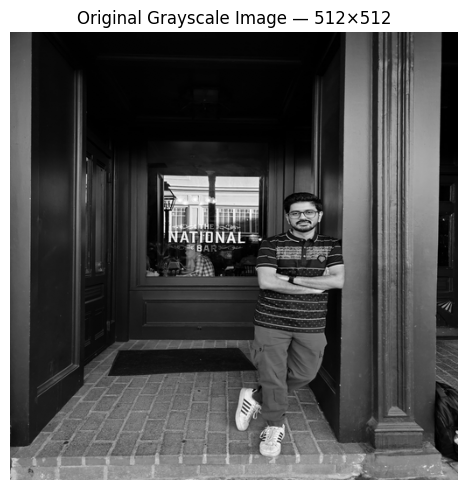

In [2]:

print("Please upload an image file (JPG, PNG, etc.):")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = Image.open(BytesIO(uploaded[filename]))

# Convert to grayscale
img = img.convert("L")

# Resize to 512×512
img = img.resize((512, 512), Image.LANCZOS)

# Ensure divisible by 8
w, h = img.size
img = img.crop((0, 0, (w // 8) * 8, (h // 8) * 8))

img_array = np.array(img, dtype=np.float64)
print(f"\n✅ Image loaded: '{filename}'  |  Shape: {img_array.shape}  |  dtype: {img_array.dtype}")

# Display original
plt.figure(figsize=(5, 5))
plt.imshow(img_array, cmap="gray", vmin=0, vmax=255)
plt.title(f"Original Grayscale Image — {img_array.shape[0]}×{img_array.shape[1]}")
plt.axis("off")
plt.tight_layout()
plt.savefig("original.png", dpi=100)
plt.show()

#
# 3. Block-wise SVD — Core Functions
#
# **`compress_block(block, k)`** applies SVD to an 8×8 block and reconstructs it
# using only the top-*k* singular values:
#
# $$\text{block}_k = U_k \cdot \Sigma_k \cdot V_k^T$$
#
# **`compress_image(img, k, block_size)`** partitions the full image into non-overlapping
# blocks, compresses each one, and recombines them into the final reconstructed image.


In [3]:

def compress_block(block: np.ndarray, k: int) -> np.ndarray:
    """
    Compress a single block using SVD, retaining only the top-k singular values.

    SVD decomposition:  block = U @ diag(Σ) @ Vᵀ
    Reconstruction:     block_k = U[:, :k] @ diag(Σ[:k]) @ Vᵀ[:k, :]

    Parameters
    ----------
    block : np.ndarray, shape (block_size, block_size)
    k     : int, number of singular values to retain

    Returns
    -------
    np.ndarray — reconstructed block, same shape as input
    """
    U, S, Vt = np.linalg.svd(block, full_matrices=False)
    U_k  = U[:, :k]       # (8, k)
    S_k  = S[:k]          # (k,)
    Vt_k = Vt[:k, :]      # (k, 8)
    return U_k @ np.diag(S_k) @ Vt_k


def compress_image(img: np.ndarray, k: int, block_size: int = 8) -> np.ndarray:
    """
    Apply block-wise SVD compression across the full image.

    Parameters
    ----------
    img        : 2D np.ndarray (H, W)
    k          : singular values to keep per block
    block_size : square block dimension (default 8)

    Returns
    -------
    np.ndarray — reconstructed image, clipped to [0, 255]
    """
    H, W = img.shape
    result = np.zeros_like(img)

    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            block = img[i:i+block_size, j:j+block_size]
            result[i:i+block_size, j:j+block_size] = compress_block(block, k)

    return np.clip(result, 0, 255)

#
# 4. Compression Ratio, Frobenius Error & PSNR
#
# **Compression Ratio** for an `n×n` block retaining `k` singular values:
#
# $$\text{Compression Ratio} = \frac{n^2}{k \cdot (n + 1 + n)} = \frac{n^2}{k(2n+1)}$$
#
# For 8×8 blocks: Original = 64 values, Compressed = `k × 17` values.
#
# **Frobenius Norm Error:** $\| A - A_k \|_F$ — measures total reconstruction error.
#
# **PSNR:** $10 \cdot \log_{10}\left(\frac{255^2}{\text{MSE}}\right)$ — higher = better quality.


In [5]:

def compression_ratio(k: int, block_size: int = 8) -> float:
    original   = block_size ** 2
    compressed = k * (2 * block_size + 1)
    return original / compressed

def frobenius_error(original: np.ndarray, reconstructed: np.ndarray) -> float:
    return np.linalg.norm(original - reconstructed, 'fro')

def psnr(original: np.ndarray, reconstructed: np.ndarray, max_val: float = 255.0) -> float:
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((max_val ** 2) / mse)

# 5. Run Compression for k = 1 … 8 (Block Size = 8×8)

In [6]:

K_VALUES   = list(range(1, 9))
BLOCK_SIZE = 8

results = {"k": [], "ratio": [], "frob_error": [], "psnr_db": []}
compressed_images = {}

print(f"{'k':>4} | {'Compression Ratio':>17} | {'Frobenius Error':>15} | {'PSNR (dB)':>10}")
print("-" * 56)

for k in K_VALUES:
    recon = compress_image(img_array, k, BLOCK_SIZE)
    compressed_images[k] = recon

    cr   = compression_ratio(k, BLOCK_SIZE)
    ferr = frobenius_error(img_array, recon)
    ps   = psnr(img_array, recon)

    results["k"].append(k)
    results["ratio"].append(cr)
    results["frob_error"].append(ferr)
    results["psnr_db"].append(ps)

    Image.fromarray(recon.astype(np.uint8)).save(f"compressed_images/k{k}_block{BLOCK_SIZE}.png")
    print(f"{k:>4} | {cr:>17.4f} | {ferr:>15.2f} | {ps:>10.2f}")


   k | Compression Ratio | Frobenius Error |  PSNR (dB)
--------------------------------------------------------
   1 |            3.7647 |         4228.88 |      29.79
   2 |            1.8824 |         2385.73 |      34.76
   3 |            1.2549 |         1370.81 |      39.58
   4 |            0.9412 |          792.71 |      44.33
   5 |            0.7529 |          439.62 |      49.45
   6 |            0.6275 |          203.24 |      56.16
   7 |            0.5378 |           66.08 |      65.91
   8 |            0.4706 |            0.00 |     299.82


# 6. Visualization — Compression Ratio & Reconstruction Error vs. k

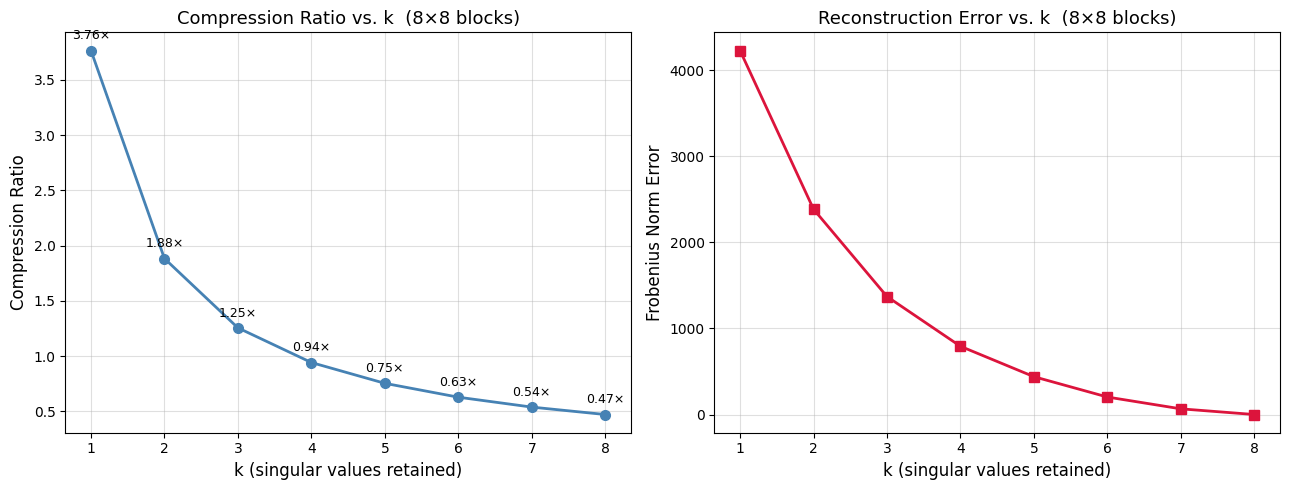

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Compression Ratio
ax = axes[0]
ax.plot(results["k"], results["ratio"], "o-", color="steelblue", linewidth=2, markersize=7)
ax.set_xlabel("k (singular values retained)", fontsize=12)
ax.set_ylabel("Compression Ratio", fontsize=12)
ax.set_title("Compression Ratio vs. k  (8×8 blocks)", fontsize=13)
ax.set_xticks(K_VALUES)
ax.grid(True, alpha=0.4)
for kv, cr in zip(results["k"], results["ratio"]):
    ax.annotate(f"{cr:.2f}×", (kv, cr), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)

# Frobenius Error
ax2 = axes[1]
ax2.plot(results["k"], results["frob_error"], "s-", color="crimson", linewidth=2, markersize=7)
ax2.set_xlabel("k (singular values retained)", fontsize=12)
ax2.set_ylabel("Frobenius Norm Error", fontsize=12)
ax2.set_title("Reconstruction Error vs. k  (8×8 blocks)", fontsize=13)
ax2.set_xticks(K_VALUES)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("metrics_8x8.png", dpi=120)
plt.show()

## 7. Visualization — PSNR vs. k

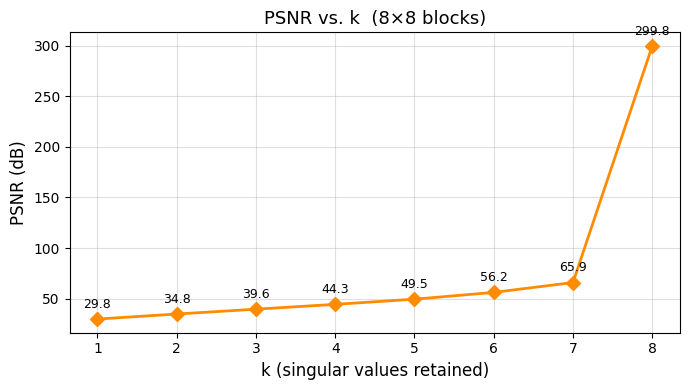

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results["k"], results["psnr_db"], "D-", color="darkorange", linewidth=2, markersize=7)
ax.set_xlabel("k (singular values retained)", fontsize=12)
ax.set_ylabel("PSNR (dB)", fontsize=12)
ax.set_title("PSNR vs. k  (8×8 blocks)", fontsize=13)
ax.set_xticks(K_VALUES)
ax.grid(True, alpha=0.4)
for kv, ps in zip(results["k"], results["psnr_db"]):
    ax.annotate(f"{ps:.1f}", (kv, ps), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("psnr_8x8.png", dpi=120)
plt.show()

# 8. Visual Quality Comparison Grid

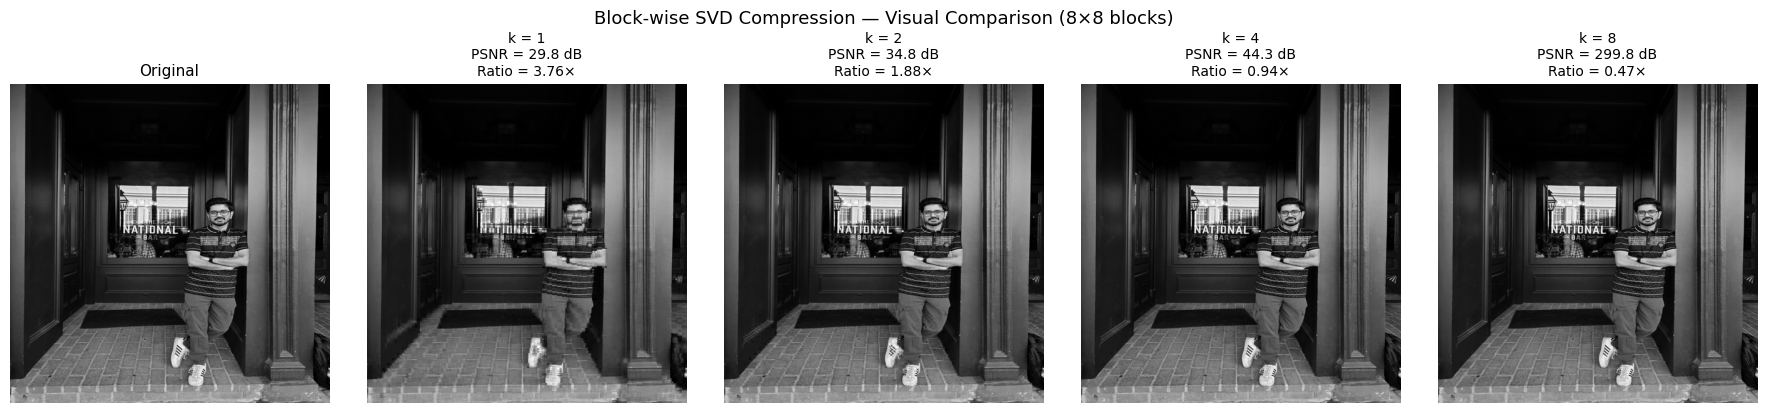

In [9]:
showcase_ks = [1, 2, 4, 8]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(img_array, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original", fontsize=11)
axes[0].axis("off")

for ax, k in zip(axes[1:], showcase_ks):
    idx = k - 1
    ax.imshow(compressed_images[k], cmap="gray", vmin=0, vmax=255)
    ax.set_title(
        f"k = {k}\nPSNR = {results['psnr_db'][idx]:.1f} dB\nRatio = {results['ratio'][idx]:.2f}×",
        fontsize=10
    )
    ax.axis("off")

plt.suptitle("Block-wise SVD Compression — Visual Comparison (8×8 blocks)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("visual_comparison_8x8.png", dpi=120, bbox_inches="tight")
plt.show()

# 9. Experiment with Other Block Sizes (4×4, 8×8, 16×16)

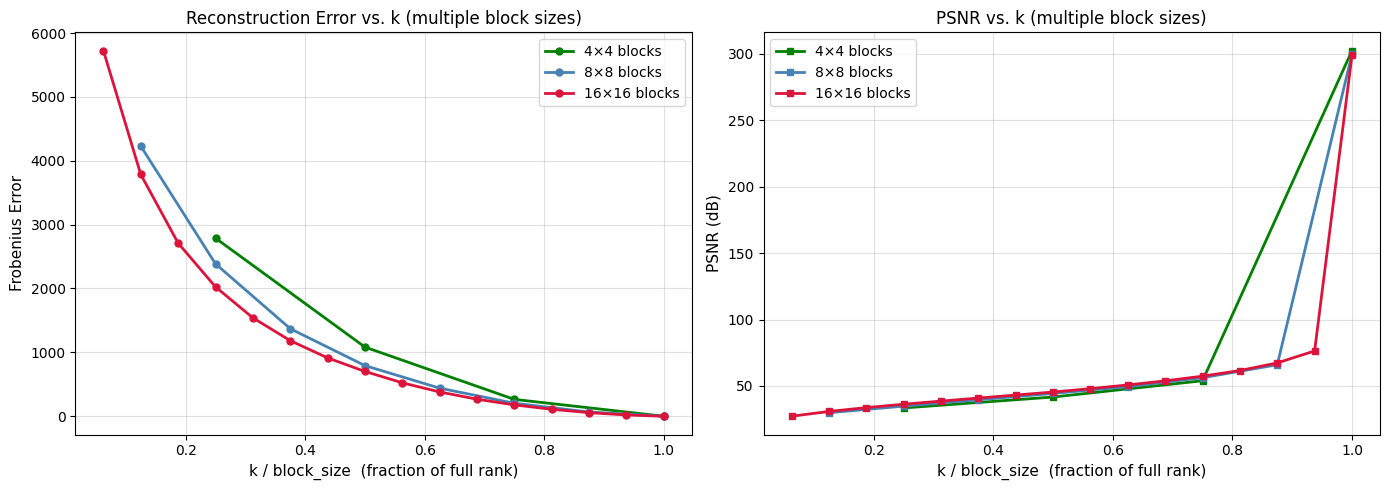

In [10]:
BLOCK_SIZES = [4, 8, 16]
block_results = {}

for bs in BLOCK_SIZES:
    bs_res = {"k": [], "ratio": [], "frob_error": [], "psnr_db": []}
    for k in range(1, bs + 1):
        recon = compress_image(img_array, k, bs)
        bs_res["k"].append(k)
        bs_res["ratio"].append(compression_ratio(k, bs))
        bs_res["frob_error"].append(frobenius_error(img_array, recon))
        bs_res["psnr_db"].append(psnr(img_array, recon))
    block_results[bs] = bs_res

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {4: "green", 8: "steelblue", 16: "crimson"}

for bs, res in block_results.items():
    k_norm = [k / bs for k in res["k"]]
    axes[0].plot(k_norm, res["frob_error"], "o-", color=colors[bs],
                 linewidth=2, markersize=5, label=f"{bs}×{bs} blocks")
    axes[1].plot(k_norm, res["psnr_db"], "s-", color=colors[bs],
                 linewidth=2, markersize=5, label=f"{bs}×{bs} blocks")

axes[0].set_xlabel("k / block_size  (fraction of full rank)", fontsize=11)
axes[0].set_ylabel("Frobenius Error", fontsize=11)
axes[0].set_title("Reconstruction Error vs. k (multiple block sizes)", fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].set_xlabel("k / block_size  (fraction of full rank)", fontsize=11)
axes[1].set_ylabel("PSNR (dB)", fontsize=11)
axes[1].set_title("PSNR vs. k (multiple block sizes)", fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("block_size_comparison.png", dpi=120)
plt.show()


#  10. Analysis & Conclusions
#
#  Compression Ratio vs. k
# The compression ratio follows **64 / (17k)** for 8×8 blocks:
# - **k=1** gives the highest ratio (~3.76×) — only 17 values stored instead of 64.
# - **k=8** gives ratio = 1.0 (full rank = no compression benefit).
# - The ratio decreases hyperbolically as k grows.
#
# Reconstruction Error vs. k
# - Frobenius error drops sharply from k=1 → k=3, then flattens — a classic **elbow** curve.
# - This is because the first few singular values capture the dominant energy of the image.
# - Beyond k=4–5, additional singular values contribute diminishing improvements.
#
# PSNR
# - PSNR rises steeply for small k and saturates around k=6–8.
# - A PSNR above ~30 dB is generally considered visually acceptable.
#
# Block Size Comparison
# | Block Size | Behavior |
# |---|---|
# | **4×4** | Low spatial redundancy; error decreases quickly but compression ratios are limited |
# | **8×8** | Good balance — standard JPEG-DCT-like trade-off |
# | **16×16** | Higher compression potential at low k, but visible block artefacts |
#
# Key Takeaway
# SVD-based block compression clearly demonstrates how low-rank matrix approximations
# preserve perceptual image quality while reducing storage. The **elbow point** around
# k=3–5 (for 8×8 blocks) represents the sweet spot between compression and fidelity.